# Calibration of a line

We'll start with the smallest problem that contains the model calibration workflow: fitting a line to noisy measured points. First, we will declare the model ($y = m x + b$), what we believe about its parameters — our [priors](https://en.wikipedia.org/wiki/Prior_probability) — and how the data compare with a given model prediction — our [likelihood](https://en.wikipedia.org/wiki/Likelihood_function). Then we compile that problem, hand it to a sampler, and draw samples from our [posterior](https://en.wikipedia.org/wiki/Posterior_probability). Finally, we push those posterior samples back through our model to generate a [posterior predictive](https://en.wikipedia.org/wiki/Posterior_predictive_distribution), and compare it to the data we fit to see if it worked. [Bayesian inference](https://en.wikipedia.org/wiki/Bayesian_inference) always has these ingredients: a prior over parameters, a likelihood for the data, and a posterior we explore with a sampler. 

In this synthetic data case, we know the ground truth, and therefore know our model is correctly specified. We also know the data-generating process: every point will scatter about the true line with the same standard deviation $\sigma$. Our imaginary experiment reports that $\sigma$ for each point, but rather than take it on trust, we'll infer it alongside $m$ and $b$. That's our first, and simplest, *error model*, and we'll check that it recovers the reported value. It will also pay off later, when we want predictions at $x$ values nobody measured. Other tutorial notebooks in this series explore the more realistic cases in which our model is only an approximation to reality, and we may not have complete information about the experimental uncertainties.

We could write this model calibration problem as follows:

\begin{equation}
 y_i + \varepsilon_i = \eta(x_i) \equiv m_\text{true} x_i + b_\text{true} =  y_m(x_i;m,b),
\end{equation}

where $y_i$ is our (synthetic) data, $\varepsilon_i$ is discrepancy between the measured $y_i$, and the ground truth $\eta(x_i)$, which we want to model using $y_m(x_i;m,b) = m x_i + b$. $m$ and $b$ are random variables, we will start with a prior for them $p(m,b)$. $\varepsilon_i$ is also a random variable, which we model as Gaussian with mean 0 and standard deviation $\sigma$:

\begin{equation}
\varepsilon_i \sim \mathcal{N}(0, \sigma^2),
\end{equation}

This determines the likelihood, and, through Bayes' rule, the posterior, we will write below.

Recipes: 1, 2, 17, 40

In [1]:
import corner
import emcee
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx
from rxmc import terms as T

plotstyle.use()

## Parameters and a model

A `Parameter` is a random variable we will do inference on. Typically, we name it, and assign it a prior (or finite bounds, which is just a uniform prior). A `Model` is a mapping from some domain space $x$ and some parameters $\alpha$ to a prediction $y_{m}$, which we want to compare to some data $y$.

We deliberately choose a prior that disagrees with the data we are about to generate: $m \sim \mathcal{N}(1, 1)$ while the truth is $m = 0.6$, so we can see the data pull the posterior away from it.

We also need a parameter for the noise level. $\sigma$ is a positive scale that could plausibly be anywhere over an order of magnitude, so we will sample its logarithm, with $\log\sigma \sim \mathcal{N}(\log 0.2, 1)$: centred a factor of two above the truth, and wide.

In [2]:
m = rx.Parameter("m", prior=stats.norm(1.0, 1.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(1.0, 1.0), latex="b")
log_sigma = rx.Parameter(
    "log_sigma", prior=stats.norm(np.log(0.2), 1.0), latex=r"\log\sigma"
)
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
line

Model(params=(m, b))

## Data

We draw twenty points from $y = m x + b$ with independent Gaussian noise of
known size $\sigma = 0.1$, which our imaginary experiment reports honestly as
`y_err`.  We keep `y_err` in the dataset, so it shows up as error bars in our
plots, but as we'll see in a moment our likelihood won't use it.

In [3]:
rng = np.random.default_rng(49)
sigma = 0.1
truth = {"m": 0.6, "b": 2.0, "log_sigma": np.log(sigma)}
x = np.linspace(0.0, 1.0, 20)
y_true = truth["m"] * x + truth["b"]
data = rx.Dataset(
    x, y_true + rng.normal(0.0, sigma, x.size), sigma * np.ones(x.size), label="toy"
)
data

Dataset('toy', n=20)

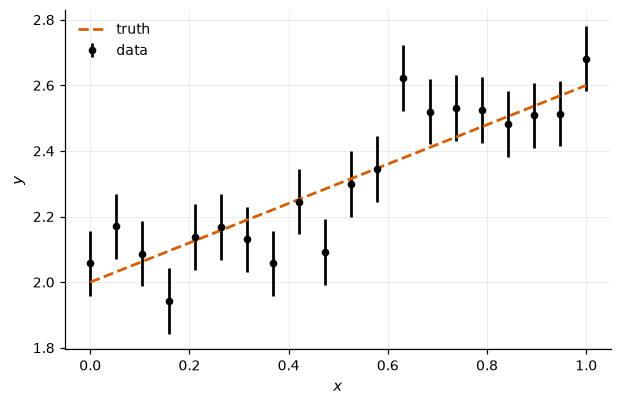

In [4]:
fig, ax = plt.subplots()
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.plot(x, y_true, "--", color=plotstyle.COLOURS[1], label="truth")
ax.set(xlabel="$x$", ylabel="$y$")
ax.legend()
plt.show()

## A comparison, a constraint and a problem

Three objects carry us from a declaration to something a sampler understands.

- A `Comparison` binds the model to this dataset's grid: it is the pairing of
  one model with one dataset.
- A `Constraint` is one likelihood over one or more comparisons, and it owns
  the *error model*: a covariance built as a sum of terms.  By default it
  includes the diagonal of the reported errors (`statistical=True`), which is
  the "the experiment told us everything" assumption.  Here we switch that off
  and add a single term, `T.noise(log_sigma)`, which puts
  $\sigma^2 = e^{2 \log\sigma}$ on the diagonal at every point.
- `Problem` compiles the lot: it gives every parameter a column, assembles the
  prior, and exposes the densities a sampler needs.

In [5]:
comp = rx.Comparison(data, line)
noise_term = T.noise(log_sigma)
problem = rx.Problem([rx.Constraint([comp], terms=[noise_term], statistical=False)])
print(problem)
print("columns:", problem.names)

Problem(ndim=3, constraints=1)
columns: ['m', 'b', 'log_sigma']


### What our prior alone predicts

Before the likelihood is involved at all, we can draw parameters from the prior
and push them through the model, noise included.  This is the
[prior predictive](https://en.wikipedia.org/wiki/Posterior_predictive_distribution#Prior_vs._posterior_predictive_distribution):
the data our prior thinks are plausible.  If it cannot produce anything like
the data we measured, we have learned something before fitting.

We draw it with `rx.predictive.grid_draws` on a plotting grid wider than the
data, and hand it prior rows instead of posterior ones.  We'll say much more
about that function once we have a posterior.

In [6]:
prior_rows = problem.sample_prior(200, rng=1)
x_fine = np.linspace(-0.5, 1.5, 60)
on_fine = line.bind(x_fine)  # the same model on a plotting grid
prior_lo, prior_mid, prior_hi = rx.predictive.grid_draws(
    problem, on_fine, x_fine, prior_rows, n_rep=5, levels=(5, 50, 95), rng=1
)

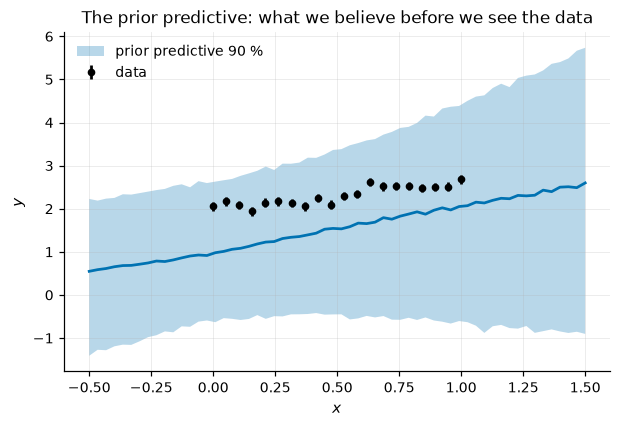

In [7]:
fig, ax = plt.subplots()
plotstyle.band(
    ax,
    x_fine,
    prior_lo,
    prior_hi,
    color=plotstyle.COLOURS[0],
    label="prior predictive 90 %",
)
ax.plot(x_fine, prior_mid, color=plotstyle.COLOURS[0])
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.set(
    xlabel="$x$",
    ylabel="$y$",
    title="The prior predictive: what we believe before we see the data",
)
ax.legend()
plt.show()

### Calibrating to data 

To determine the posterior $p(m,b,\sigma | y ) $, we use Bayes' rule:

\begin{equation}
p(m,b,\sigma | y )  = \frac{1}{\mathcal{Z}} \, L(y | m,b,\sigma) \, p(m,b)p(\sigma)
\end{equation}

The relation between $y_i$, $\varepsilon_i$, and $y_m(x_i;m,b)$ above gives us the following log-likelihood:

\begin{align*}
\log L(m,b,\sigma) &= -\frac{1}{2}\chi^2(m,b,\sigma) - N \log\sigma - \frac{N}{2}\log 2\pi\\
\chi^2(m,b,\sigma) &= \sum_i \frac{(y_i - y_m(x; m,b))^2}{\sigma^2}
\end{align*}

If $\sigma$ were fixed, the last two terms in $L$ would be constants and we could
forget about them - optimizing $m$ and $b$ to maximize the log-likelihood would then simply reduce to good old least-squares, or $\chi^2$-minimization.  Because we also infer $\sigma$, they matter: we could always make the $\chi^2$ smaller by inflating $\sigma$, and the $-N\log\sigma$ term — the log-determinant of the covariance — is what charges us for doing so. One could still do an optimization to find the Maximum Likelihood Estimate (MLE); the $m$, $b$, and $\sigma$ maximizing $L(m,b,\sigma|y)$. However, by invoking Bayes' rule and using our priors, we will instead draw samples from the posterior.  

`problem.chi2` is the [$\chi^2$](https://en.wikipedia.org/wiki/Goodness_of_fit#Regression_analysis)
and `problem.log_likelihood` is the whole thing, so we can check both against the sums we'd type out ourselves.  When the covariance stops being diagonal — and it will, in every other notebook — the $\chi^2$ becomes the [Mahalanobis distance](https://en.wikipedia.org/wiki/Mahalanobis_distance).

In [8]:
theta0 = np.array([1.0, 1.0, np.log(0.2)])  # the prior mean, in problem.names order
on_data = line.bind(x)
s0 = np.exp(theta0[problem.columns(log_sigma)]).item()
resid = data.y - on_data(*theta0[problem.columns(line.params)])
chi2_by_hand = np.sum((resid / s0) ** 2)
loglike_by_hand = (
    -0.5 * chi2_by_hand - x.size * np.log(s0) - 0.5 * x.size * np.log(2 * np.pi)
)
print(
    f"problem.chi2           = {problem.chi2(theta0):9.3f}   by hand = {chi2_by_hand:9.3f}"
)
print(
    f"problem.log_likelihood = {problem.log_likelihood(theta0):9.3f}   "
    f"by hand = {loglike_by_hand:9.3f}"
)

problem.chi2           =   335.902   by hand =   335.902
problem.log_likelihood =  -154.141   by hand =  -154.141


We start the walkers in a small ball around the prior mean `theta0`, rather than from independent prior draws: with $\sigma$ free, a draw can strand a walker where the noise is large enough to explain everything, and the ensemble takes a long time to reel it back in.

## Running the calibration with emcee

The problem exposes everything a sampler needs: `log_posterior` is the density, `sample_prior` gives the walkers somewhere to start, and `ndim` is the dimension.  We use [emcee](https://emcee.readthedocs.io/), the affine-invariant ensemble sampler of [Goodman & Weare (2010)](https://doi.org/10.2140/camcos.2010.5.65), described in [Foreman-Mackey et al. (2013)](https://arxiv.org/abs/1202.3665).  Nothing here is specific to it: any other third-party sampler, like ptemcee, dynesty or pymc, can be used. [Black Box Bayes](https://github.com/beykyle/black-box-bayes/) provides a uniform interface to all of these that works seamlessly with `rxmc`, which is useful for production-scale inference. For the small problems in these tutorial notebooks, we can just run the samplers directly.

The chain of samples from the posterior comes back in `problem.names` order, so we always look columns up by name through `problem.columns`, never by position.

In [9]:
%%time
n_walkers, n_steps = 32, 3000
sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
sampler.random_state = np.random.RandomState(2).get_state()
start = theta0 + 1e-2 * np.random.default_rng(3).standard_normal(
    (n_walkers, problem.ndim)
)
sampler.run_mcmc(start, n_steps, progress=False)
samples = sampler.get_chain(discard=500, thin=5, flat=True)
print(
    f"{samples.shape[0]} posterior rows, "
    f"acceptance {sampler.acceptance_fraction.mean():.2f}"
)

16000 posterior rows, acceptance 0.64
CPU times: user 46.5 s, sys: 14.9 ms, total: 46.6 s
Wall time: 46.6 s


In [10]:
for name, parameter in zip(problem.names, problem.params):
    col = samples[:, problem.columns(parameter)]
    print(
        f"{name:9s} = {col.mean():6.3f} +/- {col.std():.3f}   (truth {truth[name]:.3f})"
    )
sigma_post = np.exp(samples[:, problem.columns(log_sigma)])
print(
    f"{'sigma':9s} = {sigma_post.mean():6.3f} +/- {sigma_post.std():.3f}   "
    f"(reported {sigma})"
)

m         =  0.644 +/- 0.085   (truth 0.600)
b         =  1.984 +/- 0.049   (truth 2.000)
log_sigma = -2.190 +/- 0.171   (truth -2.303)
sigma     =  0.114 +/- 0.020   (reported 0.1)


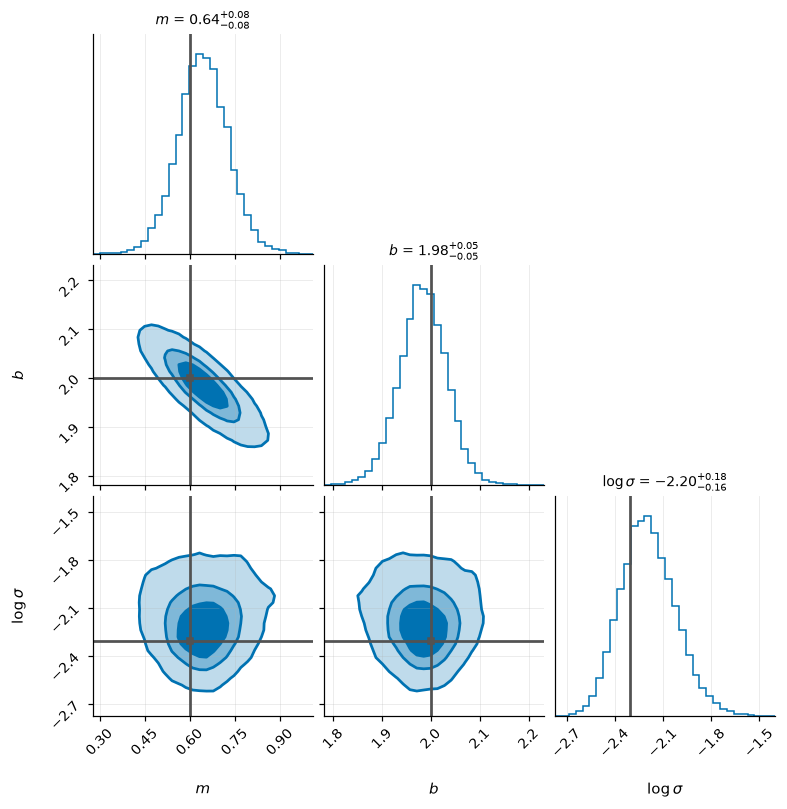

In [11]:
fig = corner.corner(
    samples,
    labels=[f"${p.latex}$" for p in problem.params],
    truths=[truth[n] for n in problem.names],
    **plotstyle.corner_kwargs(),
)
plt.show()

## The posterior predictive on any grid

The model $y = m x + b$ is not tied to the grid $x,y$ our experimental data is on: binding it to a finer, wider grid gives us the prediction where we have no data — a forecast.

But a forecast of *what*? There are two different posterior predictive distributions we might mean:

1. **The model alone**, $y_m(x_*;\theta)$ with $\theta = {m,b}$ drawn from the posterior. This is our uncertainty about the *line*: where the true curve is. If we are comparing to the ground truth, this is the predictive distribution to use.
2. **The model plus our error model**, $y_* = y_m(x_*;\theta) + \varepsilon$ with $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ and $\sigma$ drawn from the posterior too. This is our uncertainty about a *new measurement* at $x_*$ - if we are comparing to data, then this is the predictive distribution to use.

To draw the second at an $x_*$ nobody measured, every piece of the error model has to *have a value* there. That's why we inferred a constant $\sigma$ instead of using the reported `y_err`: a reported error is one number per measured point, and it says nothing about a point that was never measured. Our noise term, on the other hand, is a function — the same $\sigma$ at any $x$ — so it can be interpolated and extrapolated along with the physics model, just like $y_m$ itself.

This is the split between rxmc's two draw functions:

- `rx.diagnostics.predictive_draws` draws at the **measured** points. Every term of the error model is defined there, reported per-point errors included, so this is what we compare against the data. 
- `rx.predictive.grid_draws` draws on **any grid**. It re-evaluates each covariance term at the new points from its own definition, so it can carry anything that is a function of $x$ and the prediction — inferred noise, a normalisation uncertainty proportional to the prediction, a Gaussian-process discrepancy — but it refuses anything that is just an array of per-point numbers.

Both return a percentile band by default, and the draws themselves with `return_draws=True`.

In [12]:
post_rows = samples[::20]
model_lo, model_mid, model_hi = rx.predictive.grid_draws(
    problem, on_fine, x_fine, post_rows, model_only=True, levels=(5, 50, 95)
)
full_lo, full_mid, full_hi = rx.predictive.grid_draws(
    problem, on_fine, x_fine, post_rows, n_rep=2, levels=(5, 50, 95), rng=5
)

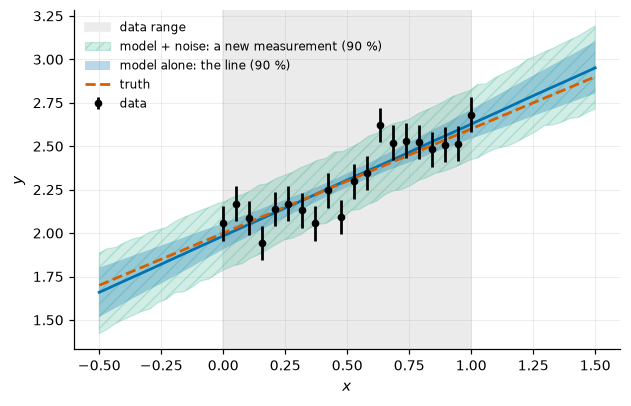

In [13]:
fig, ax = plt.subplots()
ax.axvspan(x.min(), x.max(), color="0.92", zorder=0, label="data range")
plotstyle.band(
    ax,
    x_fine,
    full_lo,
    full_hi,
    color=plotstyle.COLOURS[2],
    hatch=plotstyle.HATCHES[0],
    label="model + noise: a new measurement (90 %)",
)
plotstyle.band(
    ax,
    x_fine,
    model_lo,
    model_hi,
    color=plotstyle.COLOURS[0],
    label="model alone: the line (90 %)",
)
ax.plot(x_fine, model_mid, color=plotstyle.COLOURS[0])
ax.plot(
    x_fine,
    truth["m"] * x_fine + truth["b"],
    "--",
    color=plotstyle.COLOURS[1],
    label="truth",
)
ax.errorbar(data.x, data.y, data.y_err, fmt="o", color="k", label="data")
ax.set(
    xlabel="$x$",
    ylabel="$y$",
)
ax.legend(fontsize=8)
plt.show()

## Is our error model calibrated?

Now we check both predictives against what we actually observed, at the
measured points, with `predictive_draws`.  If a predictive distribution is properly calibrated, a central 68 % interval of its draws should contain about 68 % of the points, and likewise at every level, so the empirical
[coverage](https://en.wikipedia.org/wiki/Coverage_probability) should follow the diagonal. Twenty points make a coarse curve, but systematically being under(over) the diaginal corresponds to under(over) covering the data, with errors being too small(too large).

We expect the model-alone predictive to undercover the data.  It isn't *wrong*; it answers a different question.  It describes where the line is, and the data don't sit on the line: each point scatters about it by $\sigma$.  Which
predictive we want depends on what we're predicting.  If it's the physical curve itself — say, a cross section we'll feed into a transport code — the model band is the right object.  If it's what a new measurement would read, we need the error model on top.

In later notebooks we'll meet a third source of uncertainty that sits between these two: *model discrepancy*, the part of the disagreement between model and reality that no choice of parameters can remove (`gp_discrepancy`,
`alpha_ca_error_model_comparison`).

In [14]:
rows = samples[::10]
draws_full = rx.diagnostics.predictive_draws(
    problem, rows, n_rep=4, rng=4, return_draws=True
)
draws_model = rx.diagnostics.predictive_draws(
    problem, rows, model_only=True, return_draws=True
)
levels = np.linspace(0.01, 0.99, 90)
c = problem.constraints[0]
coverage_full = rx.diagnostics.coverage_curve(draws_full, c.y[c.active], levels)
coverage_model = rx.diagnostics.coverage_curve(draws_model, c.y[c.active], levels)

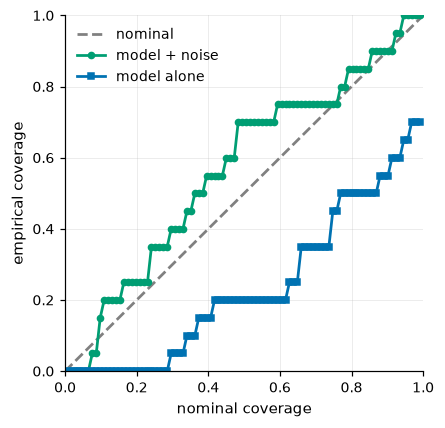

In [15]:
fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.plot([0, 1], [0, 1], "--", color="0.5", label="nominal")
ax.plot(levels, coverage_full, "o-", color=plotstyle.COLOURS[2], label="model + noise")
ax.plot(levels, coverage_model, "s-", color=plotstyle.COLOURS[0], label="model alone")
ax.set(
    xlabel="nominal coverage",
    ylabel="empirical coverage",
    xlim=(0, 1),
    ylim=(0, 1),
)
ax.legend()
plt.show()